In [1]:
from RNN_Sequences.chicago_transit_data import load_ridership_data
from data_loaders.TimeSeriesDataset import TimeSeriesDataset
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import pandas as pd
import torch
import torchmetrics

data_scale = 1e6

df_original = load_ridership_data()[:datetime(2020, 3, 1)]
df = df_original[["rail"]] / data_scale
df["next_day_type"] = df_original["day_type"].shift(-1)
df = pd.get_dummies(df, dtype=float)
print("Min: ", df.index.min())
print("Max: ", df.index.max())

Min:  2001-01-01 00:00:00
Max:  2020-03-01 00:00:00


In [2]:
start_date = df.index.min()
valid_start_date = df.index[int(len(df) * 0.6)]
test_start_date = df.index[int(len(df) * 0.8)]

print(start_date, valid_start_date, test_start_date)

2001-01-01 00:00:00 2012-07-02 00:00:00 2016-05-02 00:00:00


In [3]:
window_length = 21

df_train = df[start_date:valid_start_date - timedelta(days=1)]
df_valid = df[valid_start_date:test_start_date - timedelta(days=1)]
df_test = df[test_start_date:]

rail_train = torch.FloatTensor(df_train.values)
rail_valid = torch.FloatTensor(df_valid.values)
rail_test = torch.FloatTensor(df_test.values)

target_slice = slice(0, 1)
train_set = TimeSeriesDataset(rail_train, window_length, target_data_slice=target_slice)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length, target_data_slice=target_slice)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length, target_data_slice=target_slice)
test_loader = DataLoader(test_set, batch_size=32)

Epoch:1 / 50, train loss: 0.0152, train metric: 0.1052, valid metric: 0.0684 (best),  in 1.4s
Epoch:2 / 50, train loss: 0.0014, train metric: 0.0392, valid metric: 0.0326,  in 1.0s
Epoch:3 / 50, train loss: 0.0012, train metric: 0.0351, valid metric: 0.0348,  in 1.0s
Epoch:4 / 50, train loss: 0.0009, train metric: 0.0305, valid metric: 0.0345,  in 1.0s
Epoch:5 / 50, train loss: 0.0009, train metric: 0.0313, valid metric: 0.0397,  in 1.0s
Epoch:6 / 50, train loss: 0.0009, train metric: 0.0290, valid metric: 0.0467,  in 1.0s
Epoch:7 / 50, train loss: 0.0009, train metric: 0.0301, valid metric: 0.0328,  in 1.0s
Epoch:8 / 50, train loss: 0.0009, train metric: 0.0294, valid metric: 0.0372,  in 1.0s
Epoch:9 / 50, train loss: 0.0009, train metric: 0.0303, valid metric: 0.0426,  in 1.0s
Epoch:10 / 50, train loss: 0.0008, train metric: 0.0278, valid metric: 0.0386,  in 1.0s
Epoch:11 / 50, train loss: 0.0009, train metric: 0.0293, valid metric: 0.0568,  in 1.0s
Epoch:12 / 50, train loss: 0.0009,

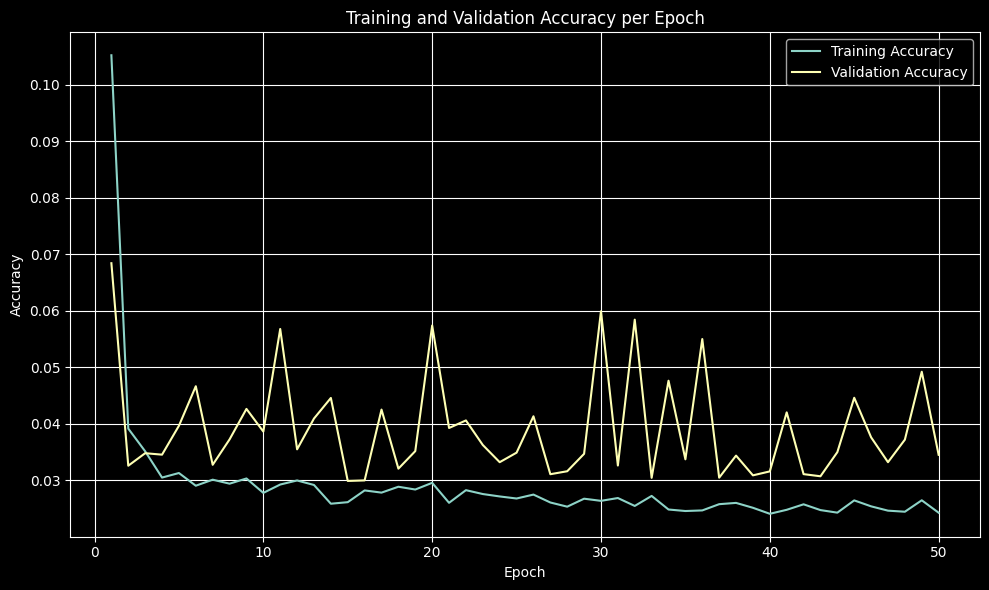

In [4]:
from graph_history import graph_history
from RNN_Sequences.chicago_transit_model import ChicagoRidershipModel
from model_runner.ModelRunner import ModelRunner
from torch import nn

torch.manual_seed(42)
model = ChicagoRidershipModel(input_size=4, hidden_size=128, output_size=1, num_layers=2)
loss_fn = nn.HuberLoss()
#optimizer = torch.optim.SGD(model.parameters(), lr=0.20, momentum=0.90)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
metric = torchmetrics.MeanAbsoluteError()

runner = ModelRunner(model, metric, optimizer, loss_fn)
history = runner.train_model(train_loader, valid_loader, n_epochs=50, patience=75)

test_metric = torchmetrics.MeanAbsoluteError()
test_result = runner.test_model(test_loader, test_metric) * 1e6
print(test_result)
graph_history(history)

In [5]:
# Note that in order to make predictions, we must have the past window_length days of data.
test_predictions = runner.run_model(test_loader).cpu()
df_test_predictions = pd.DataFrame(test_predictions)[[0]]
df_test_predictions = df_test_predictions * data_scale
df_test_predictions.columns = ["predicted_rail"]

start_row_num = df_original.index.get_loc(test_start_date) + window_length
predictions_index = df_original.index[start_row_num:start_row_num + len(df_test_predictions)]
df_test_predictions.index = predictions_index
df_test_predictions

,predicted_rail
date,
2016-05-23,655796.062500
2016-05-24,715272.000000
2016-05-25,729509.875000
2016-05-26,713005.250000
2016-05-27,709435.687500
...,...
2020-02-26,715601.000000
2020-02-27,695674.687500
2020-02-28,689813.062500


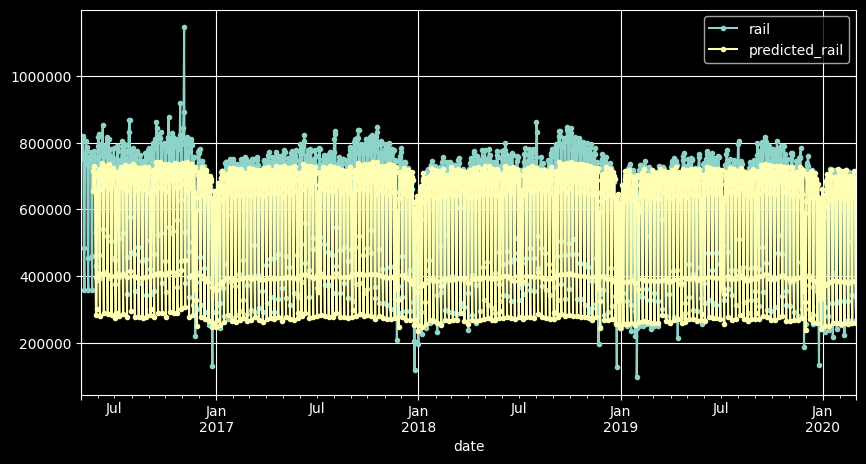

In [6]:

df_test = df_original[test_start_date:][["rail"]]
df_combined = df_test.join(df_test_predictions, how = "left")

df_combined.plot(grid=True, marker=".", figsize=(10, 5))
plt.ticklabel_format(style='plain', axis='y')
plt.show()

<Axes: xlabel='date'>

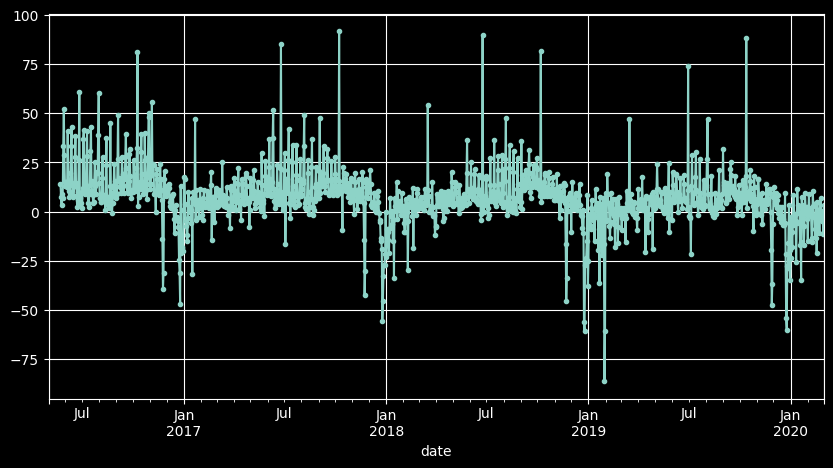

In [10]:
df_combined["error"] = df_combined["rail"] - df_combined["predicted_rail"]
df_combined["percentage_error"] = (df_combined["error"] / df_combined["predicted_rail"]) * 100
df_combined["percentage_error"].plot(grid=True, marker=".", figsize=(10, 5))

In [11]:
df_combined

,rail,predicted_rail,error,percentage_error
date,,,,
2016-05-02,751259,NaN,NaN,NaN
2016-05-03,769834,NaN,NaN,NaN
2016-05-04,767760,NaN,NaN,NaN
2016-05-05,818665,NaN,NaN,NaN
2016-05-06,814758,NaN,NaN,NaN
...,...,...,...,...
2020-02-26,682501,715601.000000,-33100.000000,-4.625483
2020-02-27,698886,695674.687500,3211.312500,0.461611
2020-02-28,665937,689813.062500,-23876.062500,-3.461237
